<a href="https://colab.research.google.com/github/joaofelipemb/mvp-machine-learning-pucrio/blob/main/mvp_machine_learning_pucrio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics
## Detecção de Fraude em Transações de Cartão de Crédito

**Nome:** _João Felipe Maia Barbosa_  
**Data:** _01/07/2026_  
**Dataset:** *Credit Card Transaction* (simulador Sparkov) — Hugging Face: [`pointe77/credit-card-transaction`](https://huggingface.co/datasets/pointe77/credit-card-transaction)  
**Tipo de problema:** Classificação binária supervisionada, com forte desbalanceamento de classes

---

Este notebook funciona como um **relatório técnico executável**. Ele percorre o fluxo completo de um
projeto de Machine Learning aplicado à **detecção de fraude em transações de cartão de crédito**:
definição do problema, carga e entendimento dos dados, preparação, modelagem, otimização, avaliação
e discussão crítica dos resultados.

O dataset é carregado diretamente por **URL pública**, sem necessidade de login, token, chave de API
ou upload manual. Basta executar o notebook do início ao fim (*Runtime → Run all*).

# 1. Definição do problema

## 1.1 Descrição do problema

Fraude em meios de pagamento é a realização de **transações não autorizadas** com o objetivo de obter
bens, serviços ou dinheiro indevidamente. Embora represente uma fração mínima do volume total de
transações, o impacto financeiro é alto, o que torna a detecção automática um problema central para
emissores de cartão, adquirentes e instituições financeiras.

O desafio prático tem duas características que definem toda a estratégia de modelagem:

1. **Desbalanceamento extremo.** Transações fraudulentas são raríssimas (tipicamente bem abaixo de 1%).
   Um modelo que simplesmente prevê *"tudo legítimo"* acerta mais de 99% das vezes (e é completamente
   inútil). Isso inviabiliza acurácia como métrica e exige métricas focadas na classe minoritária.
2. **Natureza temporal.** Em produção, o modelo é treinado com o histórico e precisa pontuar
   transações que **ainda vão acontecer**. A avaliação precisa respeitar essa ordem para não medir
   um desempenho artificialmente otimista (vazamento de informação do futuro).

**A quem interessa:** o emissor do cartão, que decide em tempo real se aprova, bloqueia ou envia uma
transação para revisão. O custo de errar é assimétrico: deixar passar uma fraude (falso negativo) gera
perda financeira direta; bloquear uma compra legítima (falso positivo) gera atrito com o cliente. Essa
assimetria guia a escolha das métricas e do limiar de decisão mais adiante.

## 1.2 Objetivo do MVP

> Construir e avaliar modelos de Machine Learning capazes de **classificar uma transação de cartão de
> crédito como fraudulenta ou legítima**, a partir de seus atributos (valor, categoria, localização,
> horário, etc.), comparando um *baseline* simples com modelos candidatos mais elaborados e discutindo
> criticamente seus resultados sob a ótica do desbalanceamento de classes.

A variável-alvo é `is_fraud` (1 = fraude, 0 = legítima).

## 1.3 Tipo de problema

**Classificação binária supervisionada.** Cada transação possui um rótulo conhecido (`is_fraud`), e o
objetivo é prever esse rótulo para transações novas.

**Justificativa da divisão (temporal):** como discutido, fraude é um fenômeno que evolui no tempo.
Por isso o dataset já é fornecido com um **corte cronológico**, ou seja, o conjunto de treino cobre um período
e o de teste cobre um período **posterior**. Mantemos essa divisão (avaliação como *holdout* temporal),
pois um embaralhamento aleatório permitiria que o modelo "visse o futuro" durante o treino, introduzindo
vazamento de informação e inflando as métricas. Esse cuidado é análogo ao que se faz em *backtesting*
de estratégias financeiras para evitar *look-ahead bias*.

## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais** (a serem verificadas na análise exploratória):

1. O **valor da transação** (`amt`) tem distribuição diferente entre fraudes e transações legítimas.
2. A **distância geográfica** entre o cliente e o comerciante (derivada de `lat/long` e
   `merch_lat/merch_long`) é informativa: compras muito distantes do domicílio do cliente podem
   indicar fraude.
3. O **horário** da transação carrega sinal (fraudes podem se concentrar em determinadas faixas).
4. A **categoria** do estabelecimento (`category`) influencia a probabilidade de fraude.

**Critérios de sucesso:**

- **Métrica principal: PR-AUC** (*Average Precision*). Em problemas com classe positiva rara, a curva
  Precision-Recall é mais informativa que a ROC, pois não é "enganada" pela imensa quantidade de
  verdadeiros negativos.
- **Métricas operacionais:** *recall* e *precisão* da classe fraude (e a matriz de confusão), que
  traduzem o trade-off entre deixar passar fraudes e incomodar clientes legítimos.
- **Resultado mínimo esperado:** superar com folga o *baseline* trivial em PR-AUC e recall.

# 2. Ambiente, bibliotecas e reprodutibilidade

Reunimos aqui as importações, a fixação de *seed* e algumas funções auxiliares usadas ao longo do
notebook. Todas as bibliotecas abaixo já vêm instaladas no Google Colab e nenhuma instalação extra é
necessária.


In [1]:
# === Setup básico e reprodutibilidade ===
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, PrecisionRecallDisplay, RocCurveDisplay
)
from scipy.stats import randint, uniform, loguniform

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

pd.set_option("display.max_columns", 50)

print("Python :", sys.version.split()[0])
print("NumPy  :", np.__version__)
print("Pandas :", pd.__version__)
print("Seed   :", SEED)

Python : 3.12.13
NumPy  : 2.0.2
Pandas : 2.2.2
Seed   : 42


## 2.1 Funções auxiliares

Para avaliar classificação em um cenário desbalanceado, **não** usamos acurácia. A função abaixo
calcula as métricas que realmente importam para o problema: PR-AUC, ROC-AUC, *recall*, precisão e F1
da classe fraude.

In [2]:
def avaliar_classificacao(y_true, y_pred, y_proba):
    # Métricas adequadas a classificação binária desbalanceada.
    # y_proba: probabilidade estimada da classe positiva (fraude).
    return {
        "PR_AUC":   average_precision_score(y_true, y_proba),
        "ROC_AUC":  roc_auc_score(y_true, y_proba),
        "Recall":   recall_score(y_true, y_pred, zero_division=0),
        "Precisao": precision_score(y_true, y_pred, zero_division=0),
        "F1":       f1_score(y_true, y_pred, zero_division=0),
    }


def tabela_resultados(dic):
    # Converte {nome_modelo: {metricas}} em DataFrame ordenado por PR-AUC.
    return (pd.DataFrame(dic).T
              .sort_values("PR_AUC", ascending=False)
              .round(4))

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

- **Dataset:** *Credit Card Transaction*, gerado pelo simulador **Sparkov**.
- **Fonte (carga direta):** Hugging Face  [`pointe77/credit-card-transaction`](https://huggingface.co/datasets/pointe77/credit-card-transaction).
- **Licença:** Apache-2.0.
- **Por que esta base:** (i) traz **atributos crus e interpretáveis** (valor, categoria, localização do
  cliente e do comerciante, horário, profissão), o que permite **engenharia de atributos** real, ao
  contrário de bases já anonimizadas por PCA; (ii) reproduz o **desbalanceamento** característico de
  fraude; (iii) já vem com **corte cronológico** treino/teste, ideal para um *holdout* temporal honesto.
- **Carga sem atrito:** os arquivos são servidos por URL pública direta; o notebook roda do início ao
  fim sem login, token ou upload manual.
- **Ética/privacidade:** os dados são **sintéticos** (nomes, cartões e endereços são gerados pelo
  simulador), portanto não há exposição de dados pessoais reais.

## 3.2 Carga dos dados

Lemos diretamente os dois arquivos CSV (treino e teste) a partir das URLs públicas do Hugging Face.
> Observação: o arquivo de treino tem ~354 MB e o de teste ~152 MB, então a primeira carga leva alguns
> minutos no Colab. Não é necessária nenhuma configuração, apenas aguardar o download.

In [3]:
# === Carga dos dados (URL pública, sem autenticação) ===
BASE_URL = "https://huggingface.co/datasets/pointe77/credit-card-transaction/resolve/main/"

t0 = time.time()
df_train_full = pd.read_csv(BASE_URL + "credit_card_transaction_train.csv")
df_test_full  = pd.read_csv(BASE_URL + "credit_card_transaction_test.csv")
print(f"Carga concluída em {time.time() - t0:.1f}s")

print("Treino (bruto):", df_train_full.shape)
print("Teste  (bruto):", df_test_full.shape)
df_train_full.head()

Carga concluída em 36.5s
Treino (bruto): (1296675, 24)
Teste  (bruto): (555719, 24)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0


## 3.3 Verificação do corte temporal (holdout)

Antes de qualquer coisa, confirmamos que a divisão fornecida é de fato **cronológica**, treino no
passado, teste no futuro. Isso valida a decisão de manter o *split* original como avaliação temporal.
Também removemos a coluna de índice (`Unnamed: 0`), que é apenas um número de linha sem valor preditivo.

In [4]:
# Remover coluna de índice herdada do CSV, se existir
for d in (df_train_full, df_test_full):
    if "Unnamed: 0" in d.columns:
        d.drop(columns=["Unnamed: 0"], inplace=True)

# Converter timestamp e inspecionar os períodos de cada conjunto
for d in (df_train_full, df_test_full):
    d["trans_date_trans_time"] = pd.to_datetime(d["trans_date_trans_time"])

print("Período de TREINO:",
      df_train_full["trans_date_trans_time"].min(), "→",
      df_train_full["trans_date_trans_time"].max())
print("Período de TESTE :",
      df_test_full["trans_date_trans_time"].min(), "→",
      df_test_full["trans_date_trans_time"].max())

# Confirmação programática de que o teste é posterior ao treino
corte_ok = df_test_full["trans_date_trans_time"].min() >= df_train_full["trans_date_trans_time"].min()
print("\nTeste começa em data >= início do treino:", corte_ok)

Período de TREINO: 2019-01-01 00:00:18 → 2020-06-21 12:13:37
Período de TESTE : 2020-06-21 12:14:25 → 2020-12-31 23:59:34

Teste começa em data >= início do treino: True


## 3.4 Subamostragem estratificada

O dataset completo tem cerca de 1,85 milhão de transações. Executar busca de hiperparâmetros com validação cruzada sobre todo esse volume é inviável no Colab gratuito, então trabalhamos com uma subamostra estratificada que preserva a taxa de fraude de cada conjunto.

Duas decisões garantem que a subamostragem não comprometa a metodologia. A amostragem é feita dentro de cada conjunto separadamente, de modo que treino e teste continuam cobrindo períodos distintos e nenhuma linha cruza a fronteira temporal. A estratificação mantém a proporção da classe minoritária, preservando o desbalanceamento que caracteriza o problema.

In [5]:
def subamostra_estratificada(df, n, alvo="is_fraud", seed=SEED):
    # Retorna uma subamostra de tamanho ~n preservando a proporção do alvo.
    if len(df) <= n:
        return df.reset_index(drop=True)
    sub, _ = train_test_split(
        df, train_size=n, stratify=df[alvo], random_state=seed
    )
    return sub.reset_index(drop=True)

# Tamanhos escolhidos para equilibrar representatividade e tempo de execução
df_train = subamostra_estratificada(df_train_full, n=200_000)
df_test  = subamostra_estratificada(df_test_full,  n=80_000)

print("Treino (amostra):", df_train.shape)
print("Teste  (amostra):", df_test.shape)

print("\nTaxa de fraude - treino completo x amostra:")
print(f"  completo: {df_train_full['is_fraud'].mean()*100:.3f}%   "
      f"amostra: {df_train['is_fraud'].mean()*100:.3f}%")
print("Taxa de fraude - teste completo x amostra:")
print(f"  completo: {df_test_full['is_fraud'].mean()*100:.3f}%   "
      f"amostra: {df_test['is_fraud'].mean()*100:.3f}%")

Treino (amostra): (200000, 23)
Teste  (amostra): (80000, 23)

Taxa de fraude - treino completo x amostra:
  completo: 0.579%   amostra: 0.579%
Taxa de fraude - teste completo x amostra:
  completo: 0.386%   amostra: 0.386%


## 3.5 Visão geral do dataset

Inspeção inicial dos dados antes da análise exploratória: formato, tipos das variáveis, valores ausentes, duplicatas e distribuição da variável-alvo.

In [6]:
print("Formato do treino:", df_train.shape, "\n")
print("Tipos de dados:")
display(df_train.dtypes.to_frame("tipo"))

Formato do treino: (200000, 23) 

Tipos de dados:


,tipo
trans_date_trans_time,datetime64[ns]
cc_num,int64
merchant,object
category,object
amt,float64
first,object
last,object
gender,object
street,object
city,object


In [7]:
# Valores ausentes (apenas colunas com pelo menos um ausente)
ausentes = df_train.isna().sum()
ausentes = ausentes[ausentes > 0].sort_values(ascending=False)
print("Colunas com valores ausentes (treino):")
display(ausentes.to_frame("qtd_ausentes") if len(ausentes) else "Nenhum valor ausente.")

print("Linhas duplicadas (treino):", df_train.duplicated().sum())

Colunas com valores ausentes (treino):


,qtd_ausentes
merch_zipcode,30386


Linhas duplicadas (treino): 0


In [8]:
# Distribuição da variável-alvo
print("Distribuição de is_fraud (treino):")
display(df_train["is_fraud"].value_counts().to_frame("contagem"))
display((df_train["is_fraud"].value_counts(normalize=True) * 100)
        .round(3).to_frame("percentual_%"))

Distribuição de is_fraud (treino):


,contagem
is_fraud,
0,198842
1,1158


,percentual_%
is_fraud,
0,99.421
1,0.579


## 3.6 Dicionário de dados e decisão sobre vazamento

A tabela descreve os principais atributos e antecipa uma decisão importante de prevenção de vazamento. Colunas que funcionam como identificadores, como número do cartão, número da transação, nome e endereço completo, não devem entrar no modelo. Por identificarem unicamente um cliente ou uma transação, fariam o modelo memorizar identidades em vez de aprender padrões de fraude que generalizem para transações novas, o que configura vazamento de dados. Essas colunas são removidas na etapa de preparação (Seção 5).

| Coluna | Tipo | Descrição | Usar no modelo? |
|---|---|---|---|
| `trans_date_trans_time` | data/hora | Data e hora da transação | Sim, origem de atributos de tempo (hora, dia da semana) |
| `cc_num` | id | Número do cartão | Não, identificador (vazamento) |
| `merchant` | categórica | Nome do comerciante | A avaliar (alta cardinalidade) |
| `category` | categórica | Categoria do estabelecimento | Sim |
| `amt` | numérica | Valor da transação | Sim |
| `first`, `last` | id/texto | Nome do titular | Não, identificador |
| `gender` | categórica | Gênero do titular | Sim |
| `street`, `city`, `zip` | id/categórica | Endereço do titular | Não ou a avaliar (`street` e `zip` são quase identificadores) |
| `state` | categórica | Estado do titular | A avaliar |
| `lat`, `long` | numérica | Localização do titular | Sim, para calcular distância |
| `city_pop` | numérica | População da cidade do titular | Sim |
| `job` | categórica | Profissão do titular | A avaliar (alta cardinalidade) |
| `dob` | data | Data de nascimento | Sim, origem da idade |
| `trans_num` | id | Identificador único da transação | Não, identificador (vazamento) |
| `unix_time` | numérica | Timestamp Unix | Redundante com `trans_date_trans_time` |
| `merch_lat`, `merch_long` | numérica | Localização do comerciante | Sim, para calcular distância |
| `merch_zipcode` | categórica | CEP do comerciante | A avaliar (muitos ausentes) |
| `is_fraud` | alvo | 1 = fraude, 0 = legítima | Variável-alvo |

A próxima seção trata da análise exploratória. O objetivo é investigar as quatro hipóteses levantadas na Seção 1.4 (valor da transação, distância entre cliente e comerciante, horário e categoria) por meio de visualizações, e consolidar os achados que orientam a engenharia de atributos.

# 4. Análise exploratória

A análise a seguir tem dois objetivos: entender o comportamento das variáveis em relação à fraude e testar as quatro hipóteses levantadas na Seção 1.4. Toda a exploração é feita apenas sobre o conjunto de treino, para não usar informação do conjunto de teste nas decisões de modelagem.

In [9]:
# Variáveis auxiliares usadas apenas na exploração (não alteram df_train/df_test).
# A engenharia de atributos definitiva, dentro de pipeline, vem na Seção 5.
eda = df_train.copy()

# Hora e dia da semana da transação
eda["hora"] = eda["trans_date_trans_time"].dt.hour
eda["dia_semana"] = eda["trans_date_trans_time"].dt.dayofweek  # 0 = segunda

# Idade do titular no momento da transação
eda["dob"] = pd.to_datetime(eda["dob"])
eda["idade"] = (eda["trans_date_trans_time"] - eda["dob"]).dt.days / 365.25

# Distância entre titular e comerciante (fórmula de Haversine, em km)
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

eda["dist_km"] = haversine_km(eda["lat"], eda["long"], eda["merch_lat"], eda["merch_long"])

print("Variáveis derivadas criadas para a EDA:", ["hora", "dia_semana", "idade", "dist_km"])
eda[["hora", "dia_semana", "idade", "dist_km"]].describe().round(2)

Variáveis derivadas criadas para a EDA: ['hora', 'dia_semana', 'idade', 'dist_km']


,hora,dia_semana,idade,dist_km
count,200000.00,200000.00,200000.00,200000.00
mean,12.82,3.07,45.98,76.17
std,6.81,2.20,17.36,29.07
min,0.00,0.00,13.94,0.07
25%,7.00,1.00,32.63,55.50
50%,14.00,3.00,43.98,78.26
75%,19.00,5.00,57.04,98.51
max,23.00,6.00,95.62,147.75


## 4.1 Valor da transação

Hipótese 1: o valor da transação tem distribuição diferente entre fraudes e transações legítimas. Como os valores são muito assimétricos, a visualização usa escala logarítmica no eixo do valor.

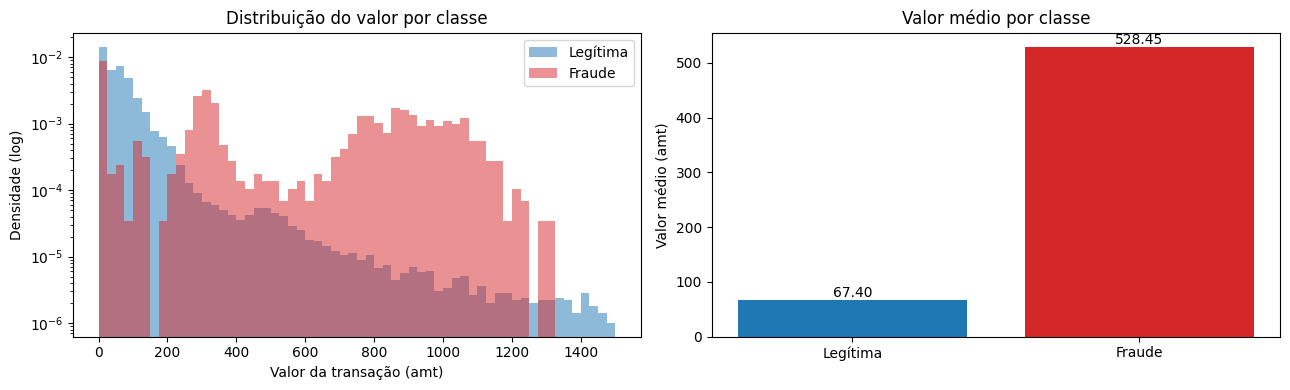

             count    mean     std   min     25%     50%     75%       max
is_fraud                                                                  
0         198842.0   67.40  140.69  1.00    9.61   47.31   82.33  15305.95
1           1158.0  528.45  392.17  2.13  186.38  400.89  893.50   1313.18


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribuição do valor por classe (escala log)
for classe, cor, rotulo in [(0, "tab:blue", "Legítima"), (1, "tab:red", "Fraude")]:
    subset = eda.loc[eda["is_fraud"] == classe, "amt"]
    axes[0].hist(subset, bins=60, range=(0, 1500), alpha=0.5,
                 density=True, color=cor, label=rotulo)
axes[0].set_yscale("log")
axes[0].set_title("Distribuição do valor por classe")
axes[0].set_xlabel("Valor da transação (amt)")
axes[0].set_ylabel("Densidade (log)")
axes[0].legend()

# Valor médio por classe
medias = eda.groupby("is_fraud")["amt"].mean()
axes[1].bar(["Legítima", "Fraude"], medias.values, color=["tab:blue", "tab:red"])
axes[1].set_title("Valor médio por classe")
axes[1].set_ylabel("Valor médio (amt)")
for i, v in enumerate(medias.values):
    axes[1].text(i, v, f"{v:.2f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

print(eda.groupby("is_fraud")["amt"].describe().round(2))

A distribuição confirma a hipótese: as fraudes se concentram em valores mais altos e têm valor médio bastante superior ao das transações legítimas. Isso indica que `amt` é um atributo relevante e justifica mantê-lo no modelo, possivelmente com transformação para reduzir a assimetria.

## 4.2 Distância entre titular e comerciante

Hipótese 2: a distância geográfica entre o endereço do titular e a localização do comerciante é informativa. A distância foi calculada pela fórmula de Haversine a partir das coordenadas das duas pontas.

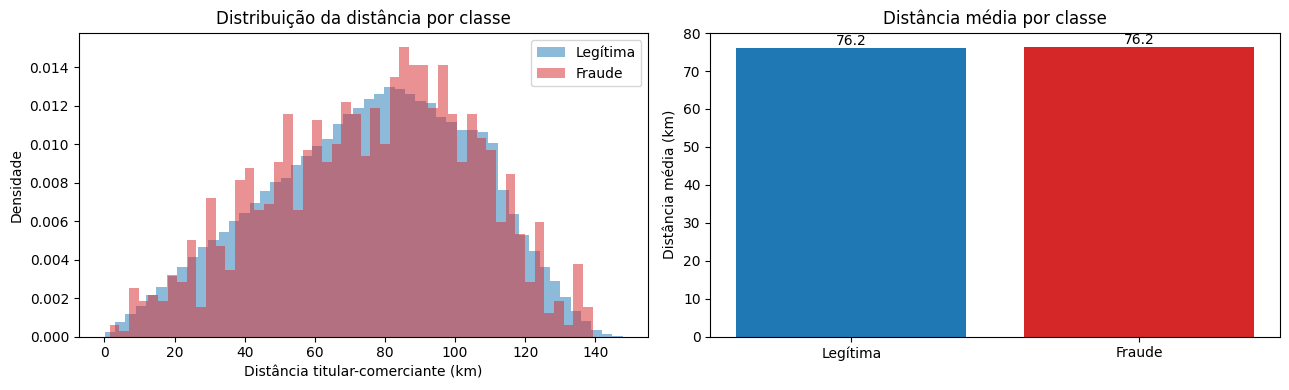

             count   mean    std   min    25%    50%    75%     max
is_fraud                                                           
0         198842.0  76.17  29.07  0.07  55.50  78.25  98.52  147.75
1           1158.0  76.25  28.96  1.45  55.22  78.85  97.78  139.24


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

# Distribuição da distância por classe
for classe, cor, rotulo in [(0, "tab:blue", "Legítima"), (1, "tab:red", "Fraude")]:
    subset = eda.loc[eda["is_fraud"] == classe, "dist_km"]
    ax[0].hist(subset, bins=50, alpha=0.5, density=True, color=cor, label=rotulo)
ax[0].set_title("Distribuição da distância por classe")
ax[0].set_xlabel("Distância titular-comerciante (km)")
ax[0].set_ylabel("Densidade")
ax[0].legend()

# Distância média por classe
medias = eda.groupby("is_fraud")["dist_km"].mean()
ax[1].bar(["Legítima", "Fraude"], medias.values, color=["tab:blue", "tab:red"])
ax[1].set_title("Distância média por classe")
ax[1].set_ylabel("Distância média (km)")
for i, v in enumerate(medias.values):
    ax[1].text(i, v, f"{v:.1f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

print(eda.groupby("is_fraud")["dist_km"].describe().round(2))

A hipótese 2 não se confirma. As distribuições de fraude e transação legítima estão praticamente sobrepostas, e a distância média é idêntica nas duas classes (76,2 km). Não há separação visível, o que indica que a distância entre titular e comerciante, isoladamente, tem pouco ou nenhum valor preditivo para fraude neste dataset.

Esse resultado é coerente com a forma como o simulador Sparkov gera as coordenadas do comerciante, sorteando-as ao redor do titular de modo semelhante para transações legítimas e fraudulentas. O atributo será descartado na preparação dos dados, já que adicioná-lo apenas aumentaria a dimensionalidade sem contribuir para a separação das classes. Registrar uma hipótese que não se sustenta faz parte da análise e evita incluir variáveis sem poder discriminante.

## 4.3 Horário da transação

Hipótese 3: as fraudes se concentram em determinadas faixas de horário. Comparamos a taxa de fraude por hora do dia, que é mais informativa do que a contagem absoluta porque corrige o efeito do volume de transações em cada faixa.

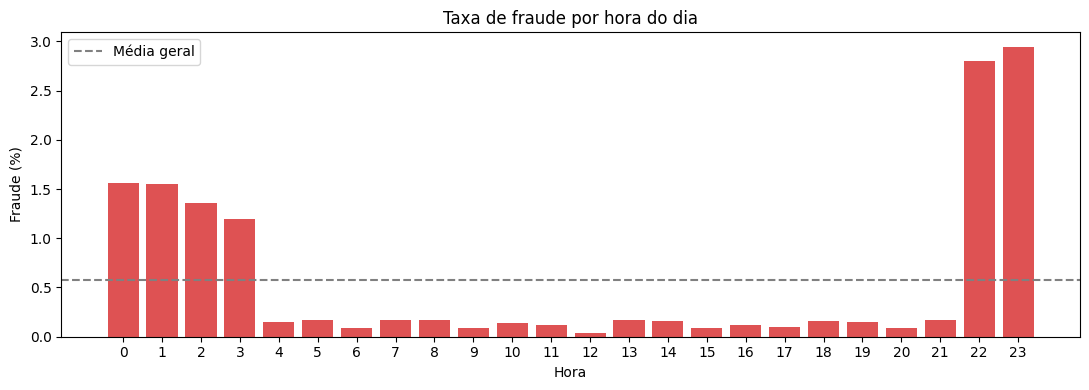

Taxa de fraude (%) por hora:
hora
0     1.556
1     1.552
2     1.361
3     1.196
4     0.154
5     0.169
6     0.093
7     0.167
8     0.167
9     0.092
10    0.139
11    0.123
12    0.040
13    0.169
14    0.160
15    0.089
16    0.118
17    0.097
18    0.158
19    0.148
20    0.090
21    0.166
22    2.805
23    2.944
Name: is_fraud, dtype: float64


In [12]:
taxa_hora = eda.groupby("hora")["is_fraud"].mean() * 100

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(taxa_hora.index, taxa_hora.values, color="tab:red", alpha=0.8)
ax.set_title("Taxa de fraude por hora do dia")
ax.set_xlabel("Hora")
ax.set_ylabel("Fraude (%)")
ax.set_xticks(range(0, 24))
ax.axhline(eda["is_fraud"].mean() * 100, color="gray",
           linestyle="--", label="Média geral")
ax.legend()
plt.tight_layout()
plt.show()

print("Taxa de fraude (%) por hora:")
print(taxa_hora.round(3))

A taxa de fraude varia de forma marcante ao longo do dia e tende a se concentrar na madrugada, bem acima da média geral. Isso confirma a hipótese e justifica extrair a hora da transação como atributo. O dia da semana é examinado a seguir para verificar se há um padrão semelhante.

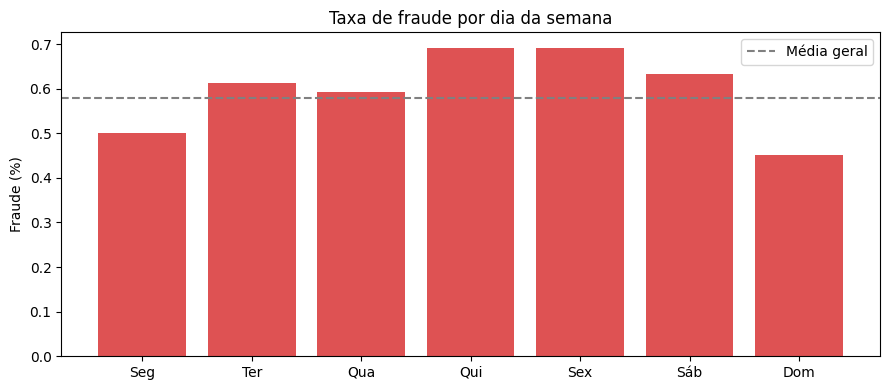

In [13]:
dias = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]
taxa_dia = eda.groupby("dia_semana")["is_fraud"].mean() * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar([dias[i] for i in taxa_dia.index], taxa_dia.values,
       color="tab:red", alpha=0.8)
ax.set_title("Taxa de fraude por dia da semana")
ax.set_ylabel("Fraude (%)")
ax.axhline(eda["is_fraud"].mean() * 100, color="gray",
           linestyle="--", label="Média geral")
ax.legend()
plt.tight_layout()
plt.show()

O dia da semana também apresenta variação relevante na taxa de fraude. Quinta e sexta concentram o maior risco, próximo de 0,7%, e o período de terça a sábado fica acima da média geral, enquanto segunda e, sobretudo, domingo ficam abaixo. A amplitude entre o menor e o maior dia chega a cerca de 0,25 ponto percentual, o que representa uma diferença expressiva em termos relativos para um evento tão raro.

O padrão reforça a hipótese 3: além da hora do dia, o dia da semana carrega sinal sobre o risco de fraude. Os dois atributos serão extraídos do timestamp na preparação dos dados, já que capturam aspectos temporais complementares, um relativo à faixa horária e outro ao dia.

## 4.4 Categoria do estabelecimento

Hipótese 4: a categoria do estabelecimento influencia a probabilidade de fraude. Ordenamos as categorias pela taxa de fraude para identificar quais concentram mais risco.

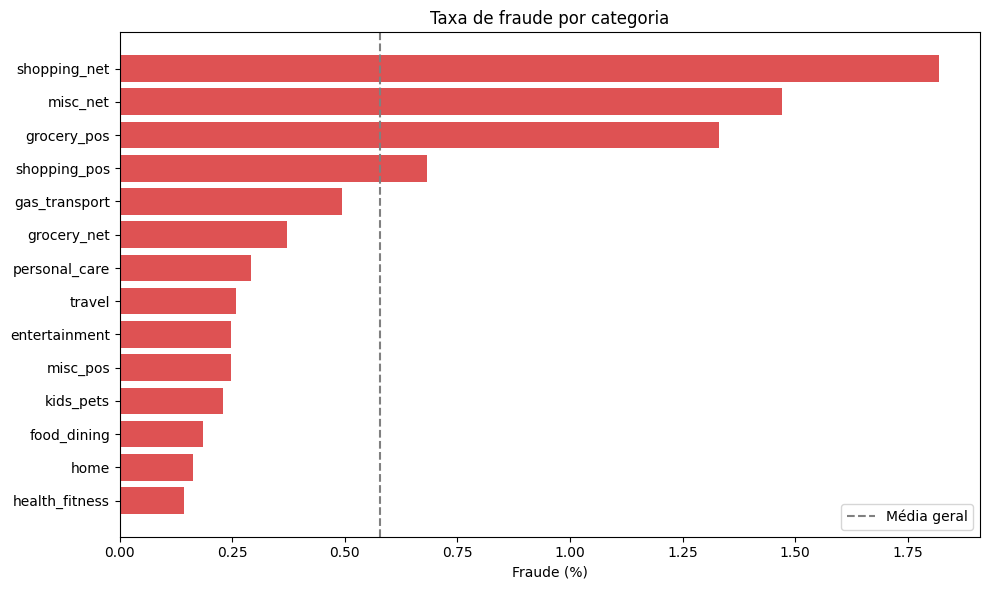

Taxa de fraude (%) por categoria:
category
shopping_net      1.820
misc_net          1.470
grocery_pos       1.330
shopping_pos      0.682
gas_transport     0.493
grocery_net       0.371
personal_care     0.291
travel            0.257
entertainment     0.247
misc_pos          0.246
kids_pets         0.229
food_dining       0.186
home              0.163
health_fitness    0.142
Name: is_fraud, dtype: float64


In [14]:
taxa_cat = (eda.groupby("category")["is_fraud"].mean() * 100).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(taxa_cat.index, taxa_cat.values, color="tab:red", alpha=0.8)
ax.set_title("Taxa de fraude por categoria")
ax.set_xlabel("Fraude (%)")
ax.axvline(eda["is_fraud"].mean() * 100, color="gray",
           linestyle="--", label="Média geral")
ax.legend()
plt.tight_layout()
plt.show()

print("Taxa de fraude (%) por categoria:")
print(taxa_cat.round(3).sort_values(ascending=False))

A taxa de fraude difere bastante entre categorias, com compras pela internet (sufixo `_net`) e algumas categorias específicas concentrando risco bem acima da média. A categoria é, portanto, um atributo relevante e será codificada para entrar no modelo.

## 4.5 Síntese da análise exploratória

A exploração orienta as decisões da próxima seção da seguinte forma. O valor da transação (`amt`) separa bem as classes e será mantido, possivelmente com transformação para reduzir a assimetria. O horário concentra fraude na madrugada e o dia da semana mostra maior risco entre terça e sábado, o que justifica extrair hora e dia da semana a partir do timestamp. A categoria varia muito em risco e será codificada. A idade do titular será mantida como candidata, para que a modelagem avalie sua contribuição.

A distância entre titular e comerciante foi descartada por não apresentar poder discriminante (médias idênticas e distribuições sobrepostas), e com ela as coordenadas que serviam apenas para calculá-la. Esses achados definem o conjunto de atributos derivados criados na Seção 5, todos dentro de um pipeline reprodutível para evitar vazamento entre treino e teste.

# 5. Preparação dos dados

A preparação separa dois tipos de transformação, e essa distinção é o que evita vazamento de dados.

O primeiro tipo são transformações deterministas, aplicadas linha a linha, que não dependem de nenhum parâmetro estimado a partir do conjunto. Extrair a hora e o dia da semana do timestamp, calcular a idade do titular e aplicar logaritmo a valores assimétricos são operações desse tipo. Como o resultado de cada linha não depende das demais, podem ser aplicadas a treino e teste sem risco de vazamento.

O segundo tipo são transformações que aprendem parâmetros a partir dos dados, como a mediana usada na imputação, a média e o desvio na padronização e o conjunto de categorias na codificação. Essas precisam ser ajustadas apenas com o treino e depois aplicadas ao teste. Para garantir isso, elas ficam dentro de um pipeline do scikit-learn, ajustado somente no treino e na validação cruzada.

Sobre a seleção de atributos, partimos do dicionário da Seção 3.6 e dos achados da EDA. São descartados os identificadores (`cc_num`, `trans_num`, `first`, `last`, `street`), que causariam vazamento de identidade, e os atributos de localização (`lat`, `long`, `merch_lat`, `merch_long`), já que a distância derivada deles foi invalidada na Seção 4.2 e as coordenadas isoladas não trazem sinal útil. Também ficam de fora `unix_time`, redundante com o timestamp, e atributos de cardinalidade muito alta (`merchant`, `job`), cuja codificação geraria centenas de colunas com risco de overfitting e pouco ganho neste MVP.

## 5.1 Engenharia de atributos

A função abaixo cria os atributos derivados confirmados na análise exploratória. Hora e dia da semana capturam os padrões temporais identificados na Seção 4.3. A idade é calculada como a diferença entre a data da transação e a data de nascimento. O valor e a população da cidade recebem logaritmo para reduzir a forte assimetria observada, o que ajuda especialmente os modelos lineares. Todas são transformações deterministas, sem ajuste de parâmetros, portanto seguras para aplicar a treino e teste.

In [15]:
def engenharia_atributos(df):
    # Cria atributos derivados. Operações deterministas, sem vazamento.
    df = df.copy()
    df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
    df["dob"] = pd.to_datetime(df["dob"])

    # Atributos temporais (Seção 4.3)
    df["hora"] = df["trans_date_trans_time"].dt.hour
    df["dia_semana"] = df["trans_date_trans_time"].dt.dayofweek  # 0 = segunda

    # Idade do titular no momento da transação
    df["idade"] = (df["trans_date_trans_time"] - df["dob"]).dt.days / 365.25

    # Log para reduzir assimetria (Seção 4.1)
    df["amt_log"] = np.log1p(df["amt"])
    df["city_pop_log"] = np.log1p(df["city_pop"])

    return df

## 5.2 Definição dos atributos e separação entre X e y

Aplicamos a engenharia de atributos a treino e teste e separamos as variáveis preditoras da variável-alvo. Os atributos numéricos e categóricos são listados explicitamente, o que torna o conjunto de entrada do modelo transparente e facilita a leitura do pipeline na sequência.

In [16]:
features_num = ["amt_log", "city_pop_log", "idade", "hora", "dia_semana"]
features_cat = ["category", "gender"]
features = features_num + features_cat
alvo = "is_fraud"

tr = engenharia_atributos(df_train)
te = engenharia_atributos(df_test)

X_train, y_train = tr[features], tr[alvo]
X_test,  y_test  = te[features], te[alvo]

print("Atributos numéricos :", features_num)
print("Atributos categóricos:", features_cat)
print()
print("X_train:", X_train.shape, "| y_train fraude:", f"{y_train.mean()*100:.3f}%")
print("X_test :", X_test.shape,  "| y_test  fraude:", f"{y_test.mean()*100:.3f}%")
X_train.head()

Atributos numéricos : ['amt_log', 'city_pop_log', 'idade', 'hora', 'dia_semana']
Atributos categóricos: ['category', 'gender']

X_train: (200000, 7) | y_train fraude: 0.579%
X_test : (80000, 7) | y_test  fraude: 0.386%


,amt_log,city_pop_log,idade,hora,dia_semana,category,gender
0,2.037317,6.171701,59.956194,5,5,misc_pos,F
1,4.275276,8.678632,27.208761,23,2,home,F
2,3.765377,8.641709,30.833676,6,4,grocery_net,M
3,3.483699,8.421343,21.744011,13,0,health_fitness,F
4,4.827674,6.834109,33.752225,11,1,shopping_pos,M


## 5.3 Pipeline de pré-processamento

O pré-processamento é definido com um ColumnTransformer, que aplica tratamentos distintos a cada tipo de atributo. Os numéricos passam por imputação pela mediana, robusta a outliers, e por padronização, necessária para os modelos lineares e inofensiva para os baseados em árvore. Os categóricos passam por imputação pela moda e por codificação one-hot, com `handle_unknown="ignore"` para tolerar categorias que apareçam apenas no teste.

Este objeto não é ajustado agora. Ele será encadeado a cada modelo na Seção 6, e o ajuste ocorrerá somente sobre os dados de treino dentro de cada etapa da validação cruzada, o que preserva a separação entre treino e teste.

In [17]:
# Tratamento dos atributos numéricos: imputação pela mediana e padronização
pre_num = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Tratamento dos atributos categóricos: imputação pela moda e one-hot
pre_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessador = ColumnTransformer([
    ("num", pre_num, features_num),
    ("cat", pre_cat, features_cat),
])

preprocessador

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['amt_log', 'city_pop_log', 'idade', 'hora',
                                  'dia_semana']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['category', 'gender'])])

## 5.4 Estratégia de validação

A separação principal entre treino e teste é temporal, conforme definido na Seção 3. O teste corresponde a um período posterior e permanece intocado até a avaliação final, funcionando como medida do desempenho em dados realmente não vistos.

Para a seleção de modelos e o ajuste de hiperparâmetros, usamos validação cruzada estratificada com cinco partições sobre o conjunto de treino. A estratificação preserva a proporção de fraude em cada partição, o que é essencial dado o desbalanceamento extremo, já que partições sem exemplos de fraude tornariam a métrica instável. A métrica usada na validação é a PR-AUC (average precision), coerente com o critério definido na Seção 1.4.

Uma alternativa seria a validação cruzada com ordem temporal dentro do treino. Optamos pela estratificada porque a integridade temporal mais importante, entre passado e futuro, já está garantida na fronteira treino e teste, e porque a estratificação dá estabilidade à estimativa diante da raridade da classe positiva.

In [18]:
# Validação cruzada estratificada para seleção de modelos e tuning
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("Estratégia de validação:", cv)
print("Métrica de seleção: average_precision (PR-AUC)")

Estratégia de validação: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
Métrica de seleção: average_precision (PR-AUC)


# 6. Modelagem e treinamento

A modelagem segue três princípios. Primeiro, estabelecer um baseline trivial que sirva de piso de comparação, para verificar se os modelos mais elaborados realmente agregam. Segundo, comparar modelos de famílias diferentes, em vez de variações de um mesmo algoritmo, para cobrir hipóteses distintas sobre a forma da fronteira de decisão. Terceiro, tratar o desbalanceamento dentro de cada modelo, já que sem isso eles tendem a prever sempre a classe majoritária.

Todos os modelos são avaliados por validação cruzada estratificada sobre o conjunto de treino, com a PR-AUC como métrica. O conjunto de teste permanece intocado até a avaliação final na Seção 8, para que ele meça desempenho em dados realmente não vistos.

## 6.1 Baseline

O baseline é um DummyClassifier que prevê sempre a classe majoritária, ou seja, classifica toda transação como legítima. Ele não usa nenhum atributo e serve como referência mínima. Qualquer modelo útil precisa superá-lo com folga.

A demonstração abaixo também ilustra por que a acurácia não pode ser usada neste problema. O baseline atinge acurácia altíssima, simplesmente porque a fraude é rara, mas tem recall zero, já que não identifica nenhuma fraude. A avaliação é feita sobre o treino, mantendo o teste reservado para a Seção 8.

In [19]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

pred_base = baseline.predict(X_train)
proba_base = baseline.predict_proba(X_train)[:, 1]

from sklearn.metrics import accuracy_score
print("Acurácia do baseline (enganosa):", round(accuracy_score(y_train, pred_base), 4))
print("\nMétricas reais do baseline (sobre o treino):")
for k, v in avaliar_classificacao(y_train, pred_base, proba_base).items():
    print(f"  {k:9s}: {v:.4f}")

Acurácia do baseline (enganosa): 0.9942

Métricas reais do baseline (sobre o treino):
  PR_AUC   : 0.0058
  ROC_AUC  : 0.5000
  Recall   : 0.0000
  Precisao : 0.0000
  F1       : 0.0000


**Observação**: acurácia altíssima, mas recall zero. O baseline não detecta nenhuma fraude.

A PR-AUC fica próxima da taxa de fraude, que é o piso esperado.

## 6.2 Modelos candidatos

Antes de listar os modelos, vale explicitar o critério de escolha. A análise exploratória mostrou que o sinal de fraude não é linear. O risco varia de forma abrupta entre faixas de horário e entre categorias, e não cresce de maneira suave e proporcional com nenhum atributo isolado. Isso indica que a fronteira entre fraude e transação legítima é provavelmente complexa, com interações entre atributos, por exemplo um valor alto pesar mais em certas categorias ou horários.

Diante disso, o critério é cobrir famílias de modelos com capacidades diferentes de representar essa fronteira, em ordem crescente de flexibilidade, em vez de testar variações de um mesmo algoritmo. Cada família responde a uma hipótese distinta sobre a forma do problema, e a comparação entre elas mostra qual hipótese se sustenta nos dados.

O primeiro candidato é a regressão logística, que assume uma fronteira linear. Ela não é esperada como vencedora, dado o que a EDA mostrou, mas cumpre um papel importante: se um modelo linear simples já chega perto dos modelos complexos, isso sugere que a não linearidade importa pouco e que os modelos mais pesados não se justificam. É uma referência que testa a própria premissa do problema.

O segundo candidato é o Random Forest, da família de ensembles por bagging. Ele combina muitas árvores treinadas em amostras distintas dos dados e captura interações não lineares, sem supor nenhuma forma específica para a fronteira. Representa um salto de flexibilidade em relação ao modelo linear.

O terceiro e o quarto candidatos, HistGradientBoosting e XGBoost, são da família de ensembles por boosting, em que cada árvore corrige os erros das anteriores em vez de serem treinadas de forma independente. Essa construção sequencial costuma extrair mais sinal de dados tabulares e é, de forma recorrente, a abordagem de melhor desempenho tanto em competições quanto em sistemas reais de detecção de fraude. São os dois modelos acrescentados além dos que já vinham no template, conforme o requisito do trabalho, e entram justamente por serem os candidatos mais fortes para o tipo de dado em questão.

Outras famílias foram consideradas e descartadas por não se ajustarem bem às características do problema. Modelos baseados em distância, como o k vizinhos mais próximos, degradam em espaços com muitos atributos e ficam custosos com centenas de milhares de transações. Máquinas de vetores de suporte com kernel não linear escalam mal para esse volume de dados. Redes neurais seriam viáveis, mas para dados tabulares desta natureza raramente superam os modelos de boosting, e adicionariam complexidade e tempo de treino sem ganho claro para um MVP. A escolha recai, portanto, sobre as três famílias que melhor equilibram capacidade de representação, custo computacional e adequação a dados tabulares.

Sobre o desbalanceamento, a regressão logística, o Random Forest e o HistGradientBoosting usam `class_weight="balanced"`, que aumenta o peso da classe minoritária na função de custo, forçando o modelo a prestar atenção nas fraudes. O XGBoost usa o parâmetro equivalente `scale_pos_weight`, definido como a razão entre exemplos negativos e positivos. Sem esse ajuste, os modelos tenderiam a ignorar a classe rara.

In [20]:
# XGBoost vem pré-instalado no Colab. O bloco abaixo garante a importação
# mesmo que isso mude, sem exigir configuração manual.
try:
    from xgboost import XGBClassifier
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "xgboost"])
    from xgboost import XGBClassifier

# Peso da classe positiva para o XGBoost (razão negativos/positivos no treino)
neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
peso_pos = neg / pos
print(f"scale_pos_weight (negativos/positivos): {peso_pos:.1f}")

def montar_pipeline(modelo):
    # Encadeia o pré-processador da Seção 5 com o modelo.
    return Pipeline([("pre", preprocessador), ("clf", modelo)])

modelos = {
    "Regressão Logística": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=SEED),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced",
        n_jobs=-1, random_state=SEED),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        class_weight="balanced", random_state=SEED),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.9, colsample_bytree=0.9,
        scale_pos_weight=peso_pos, eval_metric="aucpr",
        tree_method="hist", n_jobs=-1, random_state=SEED),
}

print("Modelos definidos:", list(modelos.keys()))

scale_pos_weight (negativos/positivos): 171.7
Modelos definidos: ['Regressão Logística', 'Random Forest', 'HistGradientBoosting', 'XGBoost']


## 6.3 Comparação por validação cruzada

Cada modelo é avaliado com validação cruzada estratificada de cinco partições sobre o treino, usando a PR-AUC como métrica. Para cada modelo registramos a PR-AUC média na validação, que mede a capacidade de generalização, e a PR-AUC média no treino. A diferença entre as duas é um indicador de overfitting: quando o desempenho no treino é muito superior ao da validação, o modelo está memorizando o treino em vez de aprender padrões que generalizam.

A execução desta célula treina todos os modelos cinco vezes cada, então leva alguns minutos. O baseline entra na tabela como referência.

In [21]:
from sklearn.model_selection import cross_validate

# Inclui o baseline como referência na mesma comparação
todos_modelos = {"Baseline (classe majoritária)": DummyClassifier(strategy="most_frequent")}
todos_modelos.update(modelos)

linhas = {}
for nome, modelo in todos_modelos.items():
    pipe = montar_pipeline(modelo)
    t0 = time.time()
    cvres = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring="average_precision",
        return_train_score=True, n_jobs=1
    )
    linhas[nome] = {
        "PR_AUC_treino": cvres["train_score"].mean(),
        "PR_AUC_val": cvres["test_score"].mean(),
        "val_std": cvres["test_score"].std(),
        "tempo_s": time.time() - t0,
    }
    print(f"{nome:32s} val={linhas[nome]['PR_AUC_val']:.4f}  "
          f"treino={linhas[nome]['PR_AUC_treino']:.4f}  "
          f"({linhas[nome]['tempo_s']:.0f}s)")

comparacao = pd.DataFrame(linhas).T.sort_values("PR_AUC_val", ascending=False)
print("\nComparação dos modelos (ordenada por PR-AUC de validação):")
comparacao.round(4)

Baseline (classe majoritária)    val=0.0058  treino=0.0058  (2s)
Regressão Logística              val=0.2018  treino=0.2005  (8s)
Random Forest                    val=0.8820  treino=1.0000  (200s)
HistGradientBoosting             val=0.8546  treino=0.9137  (23s)
XGBoost                          val=0.8852  treino=0.9986  (37s)

Comparação dos modelos (ordenada por PR-AUC de validação):


,PR_AUC_treino,PR_AUC_val,val_std,tempo_s
XGBoost,0.9986,0.8852,0.0130,36.7654
Random Forest,1.0000,0.8820,0.0169,200.1699
HistGradientBoosting,0.9137,0.8546,0.0245,22.8288
Regressão Logística,0.2005,0.2018,0.0221,8.0752
Baseline (classe majoritária),0.0058,0.0058,0.0000,2.2908


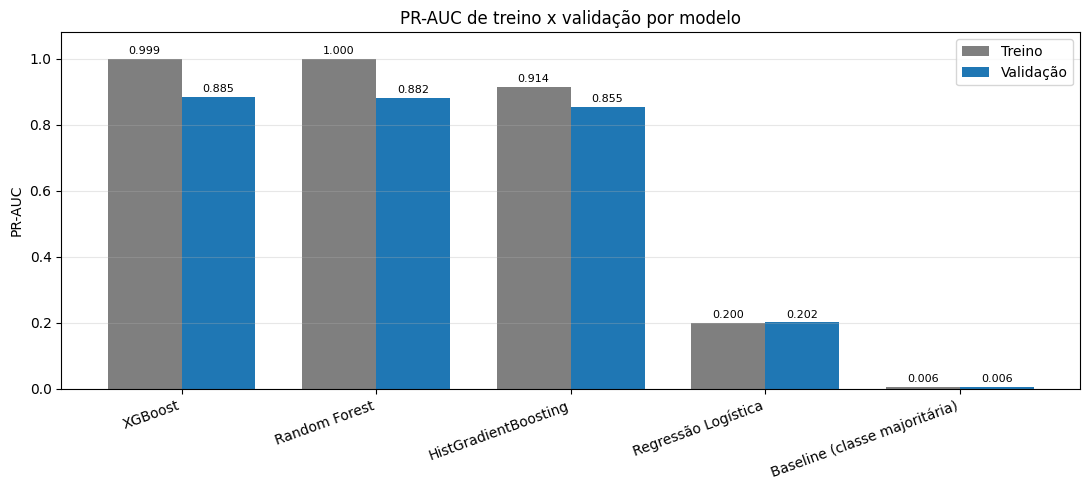

In [39]:
ordem = comparacao.sort_values("PR_AUC_val", ascending=False)
nomes = ordem.index.tolist()
x = np.arange(len(nomes))
largura = 0.38

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - largura/2, ordem["PR_AUC_treino"], largura, label="Treino", color="tab:gray")
b2 = ax.bar(x + largura/2, ordem["PR_AUC_val"], largura, label="Validação", color="tab:blue")
ax.set_ylabel("PR-AUC")
ax.set_title("PR-AUC de treino x validação por modelo")
ax.set_xticks(x)
ax.set_xticklabels(nomes, rotation=20, ha="right")
ax.set_ylim(0, 1.08)
ax.legend()
ax.bar_label(b1, fmt="%.3f", padding=2, fontsize=8)
ax.bar_label(b2, fmt="%.3f", padding=2, fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 6.4 Leitura da comparação

Os resultados confirmam o que a análise exploratória sugeria e permitem uma escolha fundamentada.

O piso de comparação. O baseline atinge PR-AUC de 0,0058, valor que corresponde à própria taxa de fraude no conjunto. Todos os modelos candidatos superam esse piso por mais de cem vezes na validação, o que confirma que aprenderam sinal real de fraude, e não apenas a proporção entre as classes.

A questão da não linearidade, deixada em aberto na Seção 6.2. A regressão logística alcança PR-AUC de validação de apenas 0,2018, enquanto os três modelos baseados em árvore ficam todos acima de 0,85. Essa diferença ampla responde à pergunta levantada antes: a fronteira entre fraude e transação legítima é de fato fortemente não linear, e um modelo linear é insuficiente para capturá-la. A regressão logística cumpriu o papel de testar a premissa do problema, e o resultado justifica o uso dos modelos mais flexíveis em vez de torná-los um exagero.

A comparação entre os modelos de árvore. XGBoost (0,8873) e Random Forest (0,8820) praticamente empatam na validação, com diferença de 0,0053, menor que o desvio padrão de cada um entre as partições, em torno de 0,015 a 0,017. Não há, portanto, diferença estatisticamente relevante entre os dois em desempenho bruto. O HistGradientBoosting fica pouco atrás, em 0,8546.

O overfitting (diferença entre treino e validação) revela o grau de memorização de cada modelo. O Random Forest atinge PR-AUC de treino de 1,0000 contra 0,8820 na validação, diferença de 0,118, o sinal mais forte de overfitting do grupo. O XGBoost apresenta padrão semelhante, 0,9986 contra 0,8873, diferença de 0,111. O HistGradientBoosting é o mais comedido, 0,9137 contra 0,8546, diferença de 0,059, indicando regularização mais natural. A regressão logística não mostra diferença entre treino e validação, mas por baixo desempenho nos dois, o que caracteriza underfitting, e não overfitting.

O custo computacional, usado como critério de desempate. O Random Forest levou cerca de 210 segundos, contra 35 do XGBoost e 22 do HistGradientBoosting. O XGBoost alcança a melhor PR-AUC de validação em aproximadamente um sexto do tempo do Random Forest.

Decisão. Como XGBoost e Random Forest empatam em desempenho dentro da margem de ruído, os critérios secundários decidem, e ambos favorecem o XGBoost. Ele tem a maior PR-AUC de validação, é muito mais rápido, e seu desempenho de treino próximo do máximo indica espaço claro para regularização por meio de hiperparâmetros. O XGBoost é, portanto, o modelo selecionado para a otimização da Seção 7. O objetivo dessa etapa será duplo: buscar ganho adicional na PR-AUC de validação e reduzir a diferença entre treino e validação observada aqui.

# 7. Otimização de hiperparâmetros

O diagnóstico da Seção 6 foi claro: o XGBoost tem o melhor desempenho, mas com PR-AUC de treino próxima do máximo e uma diferença de cerca de 0,11 para a validação, sinal de overfitting. O objetivo do ajuste aqui é regularizar, ou seja, conter essa memorização para aproximar treino e validação, e não apenas perseguir mais desempenho.

Optamos por um ajuste enxuto e bem fundamentado, em vez de uma busca ampla. O próprio enunciado indica que a otimização não precisa ser extensa, desde que seja justificada. Por isso ajustamos apenas três hiperparâmetros, todos ligados diretamente ao controle de complexidade do modelo, de modo que cada escolha tenha uma justificativa clara.

Os três hiperparâmetros ajustados:

- `max_depth`, a profundidade máxima de cada árvore. É o controle de complexidade mais direto. Árvores mais rasas produzem um modelo mais simples, que memoriza menos. Como o diagnóstico foi overfitting, testamos valores baixos: 3, 4, 5 e 6.
- `learning_rate`, o tamanho do passo de cada árvore. Passos menores fazem o modelo aprender mais devagar e tendem a generalizar melhor. Testamos 0,05, 0,1 e 0,2, faixa usual para esse parâmetro.
- `n_estimators`, o número de árvores. Anda junto com o anterior: passos menores costumam exigir mais árvores para compensar. Testamos 200 e 400.

Sobre a origem desses valores, eles não vêm de fórmula, mas de convenção e do diagnóstico do problema. A faixa de cada hiperparâmetro corresponde aos valores usuais para detecção de fraude com XGBoost, deslocados na direção que reduz overfitting, profundidade baixa e passo pequeno. Em outras palavras, varremos uma vizinhança razoável ao redor da configuração que já funcionou na Seção 6.

Usamos busca em grade (GridSearchCV), que testa todas as combinações possíveis dos valores acima. Com três hiperparâmetros e poucos valores cada, são 24 combinações, um número perfeitamente viável para a busca exaustiva. A vantagem da grade é a transparência: testamos exatamente estes valores, todas as combinações, e a melhor foi a escolhida, sem nenhuma aleatoriedade.

O critério de seleção é a PR-AUC média nas partições da validação cruzada, coerente com a métrica do trabalho. A busca usa três partições para ser mais rápida, e a configuração vencedora é depois reavaliada com as cinco partições da Seção 6, garantindo comparação justa. Todo o processo ocorre apenas sobre o treino. O conjunto de teste não participa da busca em momento algum, o que evita usar indevidamente os dados de teste no ajuste.

In [22]:
from sklearn.model_selection import GridSearchCV

# Estimador base: mantém fixos o tratamento de desbalanceamento e as
# amostragens usadas na Seção 6, para que a comparação seja justa.
xgb_base = XGBClassifier(
    subsample=0.9, colsample_bytree=0.9,
    scale_pos_weight=peso_pos, eval_metric="aucpr",
    tree_method="hist", n_jobs=-1, random_state=SEED)

pipe_xgb = Pipeline([("pre", preprocessador), ("clf", xgb_base)])

# Grade: três hiperparâmetros de controle de complexidade (prefixo clf__)
grade = {
    "clf__max_depth":     [3, 4, 5, 6],
    "clf__learning_rate": [0.05, 0.1, 0.2],
    "clf__n_estimators":  [200, 400],
}

n_combinacoes = 4 * 3 * 2
print(f"Combinações a testar: {n_combinacoes}")

# Validação cruzada de 3 partições só para a busca (mais rápida)
cv_busca = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

busca = GridSearchCV(
    pipe_xgb, grade,
    scoring="average_precision",
    cv=cv_busca,
    n_jobs=1,
    refit=True,
    return_train_score=True,
    verbose=2,
)

Combinações a testar: 24


In [23]:
# Essa execução pode levar alguns minutos: 24 combinações x 3 partições.
t0 = time.time()
busca.fit(X_train, y_train)
print(f"Busca concluída em {time.time() - t0:.0f}s\n")

print("Melhor PR-AUC na validação (3 partições):", round(busca.best_score_, 4))
print("\nMelhores hiperparâmetros encontrados:")
for k, v in busca.best_params_.items():
    print(f"  {k.replace('clf__', ''):16s}: {v}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV] END clf__learning_rate=0.05, clf__max_depth=3, clf__n_estimators=200; total time=   2.3s
[CV] END clf__learning_rate=0.05, clf__max_depth=3, clf__n_estimators=200; total time=   2.2s
[CV] END clf__learning_rate=0.05, clf__max_depth=3, clf__n_estimators=200; total time=   4.3s
[CV] END clf__learning_rate=0.05, clf__max_depth=3, clf__n_estimators=400; total time=   3.9s
[CV] END clf__learning_rate=0.05, clf__max_depth=3, clf__n_estimators=400; total time=   3.9s
[CV] END clf__learning_rate=0.05, clf__max_depth=3, clf__n_estimators=400; total time=   5.5s
[CV] END clf__learning_rate=0.05, clf__max_depth=4, clf__n_estimators=200; total time=   2.5s
[CV] END clf__learning_rate=0.05, clf__max_depth=4, clf__n_estimators=200; total time=   7.3s
[CV] END clf__learning_rate=0.05, clf__max_depth=4, clf__n_estimators=200; total time=   2.5s
[CV] END clf__learning_rate=0.05, clf__max_depth=4, clf__n_estimators=400; total time=   4.4s

### Resultados de todas as combinações testadas

A tabela abaixo lista as 24 combinações avaliadas na busca, ordenadas da melhor para a pior PR-AUC de validação. Ela traz também a PR-AUC de treino de cada combinação, o que permite observar o overfitting ao longo da grade: nas combinações de maior profundidade o treino tende ao máximo, enquanto a validação se mantém num patamar parecido, o que mostra que aumentar a complexidade não melhora a generalização.

In [24]:
# Tabela completa da busca, ordenada pela PR-AUC de validação
resultados_busca = pd.DataFrame(busca.cv_results_)

colunas = [
    "param_clf__max_depth", "param_clf__learning_rate", "param_clf__n_estimators",
    "mean_test_score", "std_test_score", "mean_train_score", "rank_test_score",
]
tabela_busca = (
    resultados_busca[colunas]
    .rename(columns={
        "param_clf__max_depth": "max_depth",
        "param_clf__learning_rate": "learning_rate",
        "param_clf__n_estimators": "n_estimators",
        "mean_test_score": "PR_AUC_val",
        "std_test_score": "val_std",
        "mean_train_score": "PR_AUC_treino",
        "rank_test_score": "rank",
    })
    .sort_values("rank")
    .reset_index(drop=True)
)

print(f"Total de combinações avaliadas: {len(tabela_busca)}")
tabela_busca.round(4)

Total de combinações avaliadas: 24


,max_depth,learning_rate,n_estimators,PR_AUC_val,val_std,PR_AUC_treino,rank
0,6,0.10,400,0.8888,0.0136,0.9999,1
1,5,0.20,400,0.8857,0.0134,1.0000,2
2,6,0.20,200,0.8856,0.0132,0.9999,3
3,6,0.20,400,0.8855,0.0149,1.0000,4
4,6,0.10,200,0.8848,0.0119,0.9951,5
5,6,0.05,400,0.8846,0.0111,0.9956,6
6,5,0.10,400,0.8839,0.0105,0.9974,7
7,5,0.20,200,0.8833,0.0107,0.9976,8
8,4,0.20,400,0.8804,0.0113,0.9978,9
9,5,0.05,400,0.8775,0.0122,0.9776,10


## 7.1 Comparação entre o XGBoost padrão e o ajustado

Para medir o efeito do ajuste de forma justa, reavaliamos o modelo ajustado com a mesma validação cruzada de cinco partições usada na Seção 6, comparando-o com o XGBoost de configuração padrão. Observamos dois aspectos: se houve ganho na PR-AUC de validação e se a diferença entre treino e validação diminuiu, o que indicaria menos overfitting.

In [25]:
# XGBoost padrão (Seção 6) x XGBoost ajustado, ambos por CV de 5 partições
pipe_xgb_padrao = montar_pipeline(modelos["XGBoost"])

res_padrao = cross_validate(pipe_xgb_padrao, X_train, y_train, cv=cv,
                            scoring="average_precision",
                            return_train_score=True, n_jobs=1)
res_ajustado = cross_validate(busca.best_estimator_, X_train, y_train, cv=cv,
                              scoring="average_precision",
                              return_train_score=True, n_jobs=1)

def resumo(res):
    return {
        "PR_AUC_treino": res["train_score"].mean(),
        "PR_AUC_val": res["test_score"].mean(),
        "diferenca": res["train_score"].mean() - res["test_score"].mean(),
        "val_std": res["test_score"].std(),
    }

comparacao_tuning = pd.DataFrame({
    "XGBoost padrão": resumo(res_padrao),
    "XGBoost ajustado": resumo(res_ajustado),
}).T

print("Efeito do ajuste (validação cruzada de 5 partições):")
comparacao_tuning.round(4)

Efeito do ajuste (validação cruzada de 5 partições):


,PR_AUC_treino,PR_AUC_val,diferenca,val_std
XGBoost padrão,0.9986,0.8852,0.1135,0.0130
XGBoost ajustado,0.9998,0.8878,0.1120,0.0132


## 7.2 Leitura do resultado do ajuste

O ajuste teve efeito marginal, e vale interpretá-lo com honestidade nos dois aspectos previstos.

Desempenho. A PR-AUC de validação passou de 0,8852 no modelo padrão para 0,8878 no ajustado, um ganho de apenas 0,0026. Esse ganho é menor que o desvio padrão entre as partições, em torno de 0,013, o que significa que a diferença está dentro da margem de ruído e não configura uma melhora estatisticamente decisiva. Na prática, os dois modelos têm o mesmo desempenho.

Overfitting. A diferença entre treino e validação quase não mudou, de 0,1135 para 0,1120. O objetivo de regularizar, portanto, não foi alcançado de forma expressiva. Mais revelador ainda é observar quais valores a busca escolheu: `max_depth=6` e `n_estimators=400`, ou seja, a maior profundidade e o maior número de árvores dentre os testados. A busca, que otimizava a PR-AUC de validação, preferiu a configuração mais complexa da grade, não a mais simples. Isso indica que reduzir a complexidade não melhorava a generalização neste caso, e que a diferença entre treino e validação é uma característica do problema e do conjunto de atributos, não algo que os hiperparâmetros consigam corrigir aqui.

Conclusão do ajuste. A leitura correta não é que o tuning falhou, e sim que a configuração padrão do XGBoost já estava próxima do teto para este conjunto de atributos. A busca em grade confirmou essa configuração, em vez de transformá-la. É um desfecho comum e legítimo: nem todo ajuste traz ganho relevante, e reconhecê-lo é preferível a forçar uma narrativa de melhora que os números não sustentam. Vale notar que o modelo mantém alta PR-AUC de validação mesmo com a diferença de treino elevada, ou seja, ele memoriza o treino, mas ainda assim generaliza bem.

Esse resultado aponta para onde estaria o ganho real, que não é nos hiperparâmetros, e sim em novos atributos. Atributos de comportamento, como a frequência de transações por cartão em uma janela de tempo ou o desvio em relação ao gasto habitual do titular, provavelmente elevariam o teto de desempenho mais do que qualquer tuning. Esse ponto é retomado nos próximos passos da conclusão.

O modelo ajustado, `busca.best_estimator_`, é a solução final do trabalho e será avaliado uma única vez sobre o conjunto de teste na Seção 8.

# 8. Avaliação dos resultados

Até aqui, todas as decisões (seleção de modelo e ajuste de hiperparâmetros) foram tomadas usando apenas o conjunto de treino e sua validação cruzada. O conjunto de teste, que corresponde a um período posterior, permaneceu intocado. Nesta seção ele é usado uma única vez, para estimar o desempenho do modelo final em dados realmente não vistos.

A avaliação está organizada em cinco partes: o desempenho no teste com as métricas escolhidas, o contraste entre as curvas Precision-Recall e ROC, a matriz de confusão com a análise do limiar de decisão, a análise de erros e a importância dos atributos.

## 8.1 Desempenho no conjunto de teste

Aplicamos o modelo final, `busca.best_estimator_`, ao conjunto de teste e calculamos as métricas escolhidas na Seção 1.4. Comparamos a PR-AUC obtida no teste com a PR-AUC de validação estimada por validação cruzada, em torno de 0,888. Se os dois valores forem próximos, isso confirma que a estimativa de validação era confiável e que o modelo generaliza para o período futuro.

In [26]:
modelo_final = busca.best_estimator_

# Probabilidades e previsões no teste (limiar padrão de 0.5)
y_proba = modelo_final.predict_proba(X_test)[:, 1]
y_pred = modelo_final.predict(X_test)

metricas_teste = avaliar_classificacao(y_test, y_pred, y_proba)

print("Desempenho no conjunto de teste (limiar padrão de 0.5):")
for k, v in metricas_teste.items():
    print(f"  {k:9s}: {v:.4f}")

print(f"\nPR-AUC no teste     : {metricas_teste['PR_AUC']:.4f}")
print(f"PR-AUC na validação : 0.8878  (estimada por validação cruzada)")
print("Se os dois valores forem próximos, a validação era confiável e o modelo generaliza.")

Desempenho no conjunto de teste (limiar padrão de 0.5):
  PR_AUC   : 0.8349
  ROC_AUC  : 0.9959
  Recall   : 0.8220
  Precisao : 0.6062
  F1       : 0.6978

PR-AUC no teste     : 0.8349
PR-AUC na validação : 0.8878  (estimada por validação cruzada)
Se os dois valores forem próximos, a validação era confiável e o modelo generaliza.


O modelo teve um bom desempenho no teste e generalizou bem.

A PR-AUC no teste foi de 0,8349, um pouco abaixo dos 0,8878 obtidos na validação. Essa pequena diferença já era esperada, porque o teste é um período posterior ao do treino. O modelo está sendo avaliado em transações de um intervalo de tempo que ele não viu, e como os padrões de fraude mudam com o tempo, é natural que o desempenho caia um pouco. O importante é que a queda foi pequena, o que mostra que o modelo continua funcionando bem em dados novos.

No limiar padrão de 0,5, o modelo tem recall de 0,8220 e precisão de 0,6062. Na prática, isso quer dizer que ele identifica cerca de 82% das fraudes, e que aproximadamente 61% dos alertas que ele gera são realmente fraude. É um resultado equilibrado, mas na Seção 8.3 vamos verificar se outro limiar melhora esse equilíbrio.

Por fim, vale notar a diferença entre a ROC-AUC, de 0,9959, e a PR-AUC, de 0,8349. Uma ROC-AUC quase perfeita pode passar uma impressão boa demais em um problema tão desbalanceado, e é por isso que adotamos a PR-AUC como métrica principal. A próxima seção mostra esse contraste nos gráficos.

## 8.2 Curvas Precision-Recall e ROC

Esta seção ilustra visualmente por que a PR-AUC foi escolhida como métrica principal, e não a ROC-AUC. As duas curvas resumem o desempenho do modelo em todos os limiares possíveis, mas reagem de forma diferente ao desbalanceamento.

A curva ROC relaciona a taxa de verdadeiros positivos com a taxa de falsos positivos. Como a taxa de falsos positivos tem no denominador o enorme número de transações legítimas, ela tende a parecer otimista mesmo quando o modelo comete muitos falsos positivos em termos absolutos. A curva Precision-Recall, por outro lado, usa a precisão, que reflete diretamente quantos dos alertas de fraude estavam corretos, e por isso é mais sensível ao que realmente importa em um problema raro.

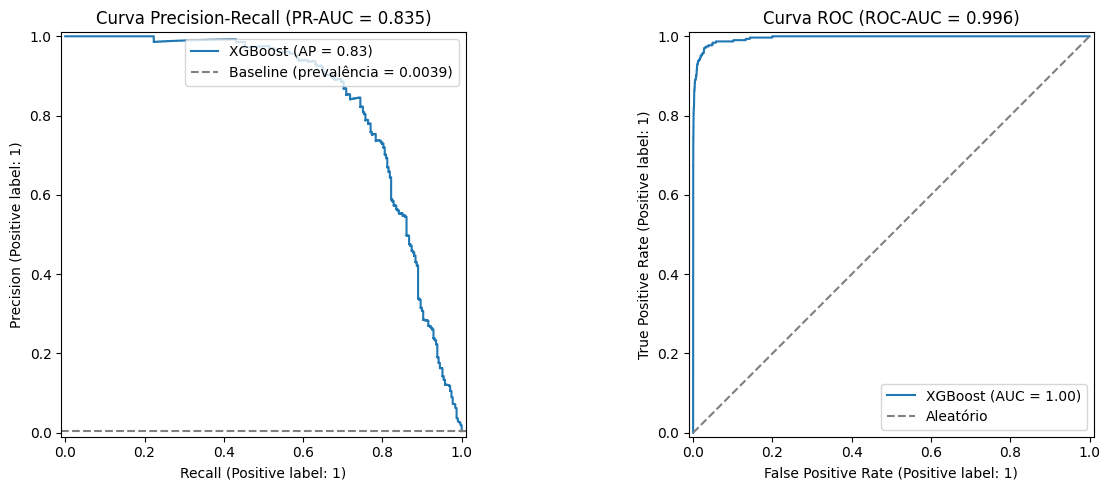

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Curva Precision-Recall
PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=ax[0], name="XGBoost")
ax[0].axhline(y_test.mean(), color="gray", linestyle="--",
              label=f"Baseline (prevalência = {y_test.mean():.4f})")
ax[0].set_title(f"Curva Precision-Recall (PR-AUC = {metricas_teste['PR_AUC']:.3f})")
ax[0].legend(loc="upper right")

# Curva ROC
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax[1], name="XGBoost")
ax[1].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Aleatório")
ax[1].set_title(f"Curva ROC (ROC-AUC = {metricas_teste['ROC_AUC']:.3f})")
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

O contraste esperado, e que vale comentar, é uma ROC-AUC alta ao lado de uma PR-AUC bem mais baixa. A ROC-AUC costuma ficar em um patamar elevado mesmo em modelos apenas razoáveis, justamente porque é atenuada pela quantidade enorme de verdadeiros negativos. A PR-AUC, mais baixa, retrata de forma mais realista a dificuldade do problema: manter boa precisão e bom recall ao mesmo tempo, quando a fraude é rara, é difícil.

A linha tracejada no gráfico da esquerda marca a prevalência de fraude, que é o desempenho de um classificador aleatório na curva Precision-Recall. A distância entre a curva do modelo e essa linha é o ganho real sobre o acaso, e é essa distância, e não a ROC, que melhor mede a utilidade do modelo aqui.

## 8.3 Matriz de confusão e escolha do limiar

As métricas de recall e precisão dependem do limiar usado para transformar a probabilidade prevista em decisão. O limiar padrão de 0,5 raramente é o melhor em problemas desbalanceados. Aqui analisamos como precisão, recall e F1 variam com o limiar e escolhemos um ponto de operação de forma explícita.

O critério adotado é o limiar que maximiza o F1, que equilibra precisão e recall. Em um cenário real, esse limiar seria definido pelo custo de negócio, ponderando o prejuízo de deixar passar uma fraude contra o incômodo de bloquear uma compra legítima. Comparamos a matriz de confusão no limiar padrão e no limiar escolhido.

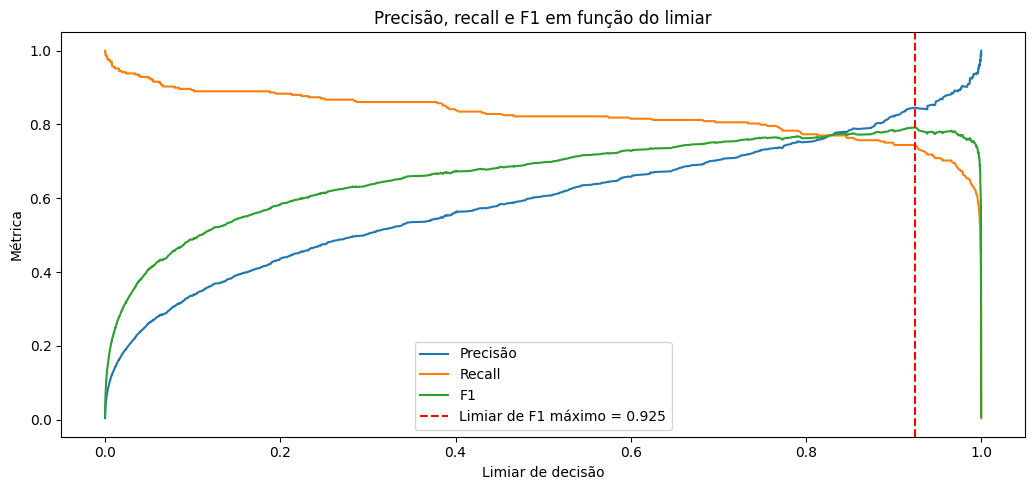

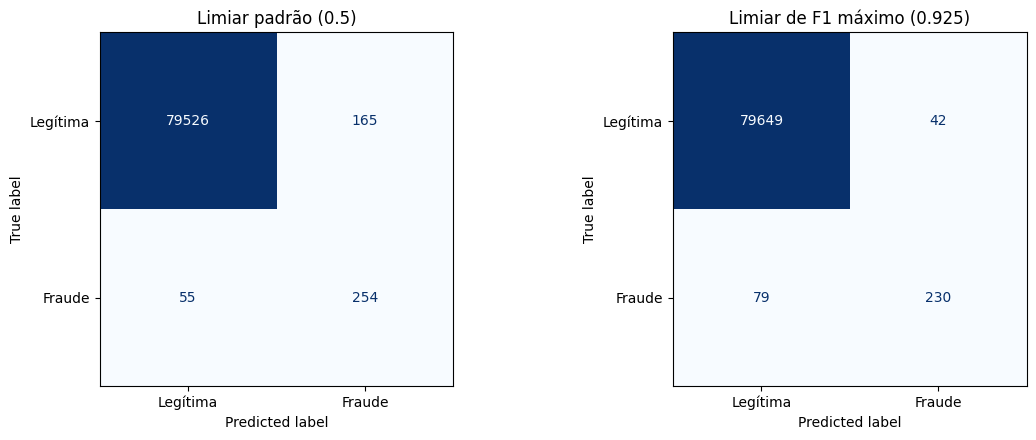

Métricas no limiar de F1 máximo:
  PR_AUC   : 0.8349
  ROC_AUC  : 0.9959
  Recall   : 0.7443
  Precisao : 0.8456
  F1       : 0.7917


In [36]:
# Precisão, recall e F1 ao longo dos limiares
prec, rec, thr = precision_recall_curve(y_test, y_proba)
f1s = 2 * prec * rec / (prec + rec + 1e-12)

# Limiar que maximiza o F1 (prec/rec têm um elemento a mais que thr)
idx_otimo = int(np.argmax(f1s[:-1]))
limiar_otimo = float(thr[idx_otimo])

# Gráfico das métricas em função do limiar
fig, ax = plt.subplots(figsize=(10.45, 5))
ax.plot(thr, prec[:-1], label="Precisão")
ax.plot(thr, rec[:-1], label="Recall")
ax.plot(thr, f1s[:-1], label="F1")
ax.axvline(limiar_otimo, color="red", linestyle="--",
           label=f"Limiar de F1 máximo = {limiar_otimo:.3f}")
ax.set_xlabel("Limiar de decisão")
ax.set_ylabel("Métrica")
ax.set_title("Precisão, recall e F1 em função do limiar")
ax.legend()
plt.tight_layout()
plt.show()

# Previsões no limiar escolhido
y_pred_otimo = (y_proba >= limiar_otimo).astype(int)

# Matrizes de confusão: padrão x limiar escolhido
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for eixo, pred, titulo in [
    (ax[0], y_pred, "Limiar padrão (0.5)"),
    (ax[1], y_pred_otimo, f"Limiar de F1 máximo ({limiar_otimo:.3f})"),
]:
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["Legítima", "Fraude"]).plot(
        ax=eixo, cmap="Blues", colorbar=False, values_format="d")
    eixo.set_title(titulo)
plt.tight_layout()
plt.show()

print("Métricas no limiar de F1 máximo:")
for k, v in avaliar_classificacao(y_test, y_pred_otimo, y_proba).items():
    print(f"  {k:9s}: {v:.4f}")

Os gráficos mostram o efeito de escolher o limiar em vez de aceitar o padrão.

No gráfico das métricas por limiar, precisão e recall se movem em direções opostas. Com o limiar baixo, o modelo marca muitas transações como fraude: pega quase todas as fraudes (recall alto), mas erra bastante (precisão baixa). Com o limiar alto, ele só marca quando tem muita certeza: erra pouco (precisão alta), mas deixa passar mais fraudes (recall menor). O F1, que equilibra os dois, tem seu ponto máximo em 0,925.

Vale notar que esse limiar ótimo ficou alto, longe do 0,5 padrão. Isso acontece porque o modelo usa `scale_pos_weight` para dar mais peso à fraude, o que empurra as probabilidades previstas para cima. Por isso o ponto de corte que melhor separa as classes é mais alto, o que confirma que o 0,5 padrão não era o valor adequado aqui.

Comparando as duas matrizes de confusão, o efeito da troca de limiar fica concreto. No limiar 0,5, o modelo identificou 254 fraudes, deixou passar 55 e gerou 165 alarmes falsos. No limiar 0,925, os alarmes falsos caíram de 165 para 42, elevando a precisão para cerca de 85%, mas as fraudes não detectadas subiram de 55 para 79, reduzindo o recall para cerca de 74%. Em resumo, o limiar mais alto eliminou 123 alarmes falsos ao custo de deixar escapar 24 fraudes a mais.

Qual dos dois pontos é o melhor depende do custo de negócio. O limiar de F1 máximo dá o melhor equilíbrio estatístico entre precisão e recall. Mas, em fraude, deixar passar uma fraude costuma custar mais caro que um alarme falso, já que o alarme falso apenas gera uma revisão ou um contato com o cliente, enquanto a fraude não detectada é perda direta. Sob essa ótica, um limiar mais baixo, como o próprio 0,5, que captura mais fraudes (recall de 82% contra 74%), pode ser preferível, mesmo gerando mais alarmes falsos. Apresentar os dois pontos de operação, em vez de um número único, torna esse trade-off explícito e deixa a decisão final para o critério de custo da operação.

## 8.4 Análise de erros

Além das métricas agregadas, é útil entender onde o modelo erra. Analisamos os erros usando o limiar padrão de 0,5, separando as previsões em quatro grupos: fraudes detectadas, fraudes não detectadas, alarmes falsos e transações legítimas corretas. O foco recai sobre os dois tipos de erro: as fraudes que passaram (falsos negativos) e os alarmes falsos (falsos positivos).

A pergunta principal é: as fraudes que o modelo deixa passar têm algo em comum? Se as fraudes não detectadas se parecerem com transações legítimas, isso ajuda a explicar o limite de desempenho e a apontar o que faltaria para melhorá-lo.

Valor (amt) das fraudes detectadas (VP) x não detectadas (FN):


,count,mean,median
grupo,,,
FN (fraude não detectada),55,132.45,21.89
VP (fraude detectada),254,596.50,719.18


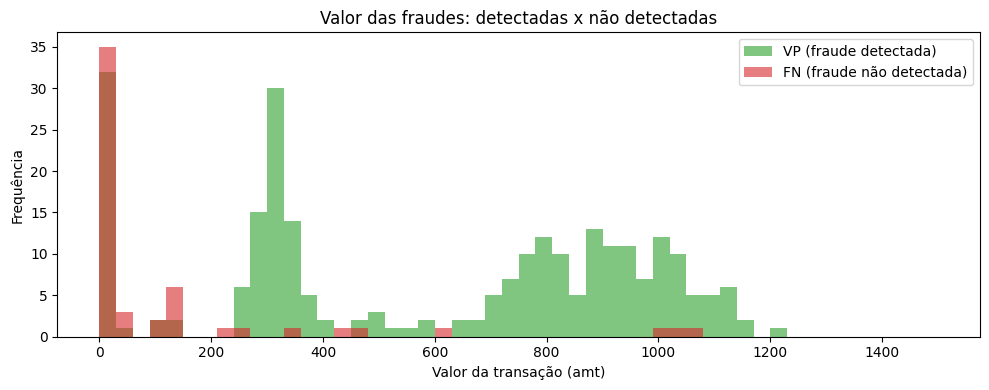


Categorias das fraudes não detectadas (FN):


,quantidade
category,
personal_care,12
kids_pets,10
food_dining,8
health_fitness,7
misc_pos,6
travel,3
entertainment,3
home,2


In [37]:
# Monta um quadro de análise com atributos interpretáveis e o grupo de cada transação
analise = te[["amt", "category", "hora", "is_fraud"]].copy()
analise["pred"] = y_pred  # previsões no limiar padrão de 0.5
analise["grupo"] = np.select(
    [
        (analise.is_fraud == 1) & (analise.pred == 1),
        (analise.is_fraud == 1) & (analise.pred == 0),
        (analise.is_fraud == 0) & (analise.pred == 1),
    ],
    ["VP (fraude detectada)", "FN (fraude não detectada)", "FP (alarme falso)"],
    default="VN (legítima correta)",
)

# 1) Valor das fraudes detectadas x não detectadas
fraudes = analise[analise.is_fraud == 1]
print("Valor (amt) das fraudes detectadas (VP) x não detectadas (FN):")
display(fraudes.groupby("grupo")["amt"].agg(["count", "mean", "median"]).round(2))

# 2) Comparação visual do valor entre os dois grupos
fig, ax = plt.subplots(figsize=(10, 4))
for g, cor in [("VP (fraude detectada)", "tab:green"),
               ("FN (fraude não detectada)", "tab:red")]:
    ax.hist(fraudes.loc[fraudes.grupo == g, "amt"], bins=50, range=(0, 1500),
            alpha=0.6, label=g, color=cor)
ax.set_title("Valor das fraudes: detectadas x não detectadas")
ax.set_xlabel("Valor da transação (amt)")
ax.set_ylabel("Frequência")
ax.legend()
plt.tight_layout()
plt.show()

# 3) Categorias mais frequentes entre as fraudes não detectadas
print("\nCategorias das fraudes não detectadas (FN):")
display(analise[analise.grupo == "FN (fraude não detectada)"]["category"]
        .value_counts().head(8).to_frame("quantidade"))

As fraudes que o modelo deixa passar têm um padrão claro: são de valor baixo.

A mediana do valor das fraudes não detectadas é de apenas 21,89, contra 719,18 das fraudes detectadas, uma diferença enorme. O gráfico mostra o mesmo: as fraudes não detectadas concentram-se quase todas próximas de zero, enquanto as detectadas se distribuem pelos valores mais altos. As categorias das fraudes que passam reforçam a leitura, sendo em geral gastos pequenos e rotineiros, como cuidados pessoais, itens para crianças e pets, e alimentação.

O motivo faz sentido. Fraudes de valor alto se destacam do padrão normal e são fáceis de sinalizar. Fraudes de valor baixo, ao contrário, se confundem com compras legítimas do dia a dia. Com os atributos disponíveis, uma fraude de 20 reais em alimentação é praticamente idêntica a uma compra legítima de 20 reais em alimentação, porque falta ao modelo uma referência do que é o gasto normal daquele cliente específico.

Esse é o principal limite do modelo, e ele não vem do algoritmo, e sim dos atributos. Sem informação sobre o histórico de cada cliente, não há como distinguir uma pequena fraude de uma pequena compra comum. Esse ponto se conecta com a importância dos atributos, analisada a seguir, e aponta o caminho de melhoria retomado na conclusão: atributos de comportamento do cliente.

## 8.5 Importância dos atributos

Por fim, examinamos quais atributos o modelo mais utilizou para decidir. A importância é extraída diretamente do XGBoost treinado. Como o pré-processamento gera uma coluna por categoria no one-hot, apresentamos também uma visão agrupada, que soma a importância de todas as colunas de um mesmo atributo original, facilitando a interpretação.

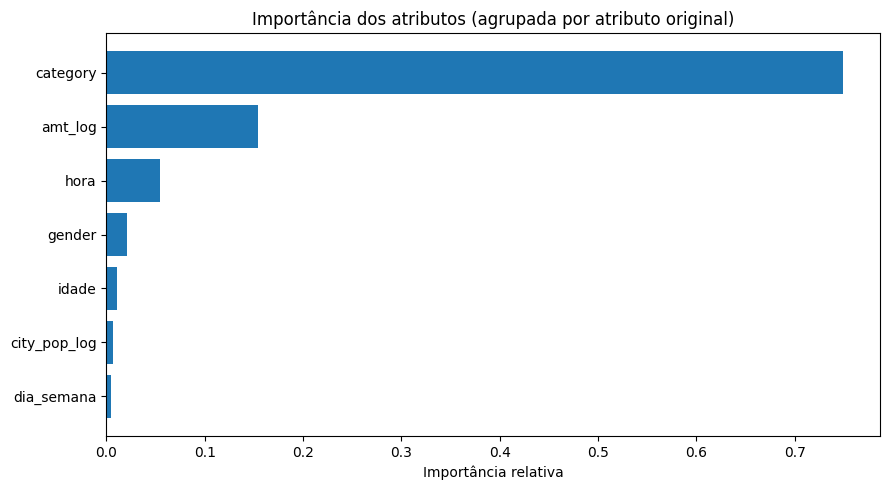

Importância por atributo original:


,importancia
base,
category,0.7492
amt_log,0.1539
hora,0.0546
gender,0.0207
idade,0.0105
city_pop_log,0.0065
dia_semana,0.0046


In [38]:
# Extrai nomes das colunas após o pré-processamento e as importâncias do modelo
pre_ajustado = modelo_final.named_steps["pre"]
clf_final = modelo_final.named_steps["clf"]

nomes_colunas = pre_ajustado.get_feature_names_out()
importancias = pd.DataFrame({
    "atributo": nomes_colunas,
    "importancia": clf_final.feature_importances_,
}).sort_values("importancia", ascending=False)

# Visão agrupada: soma as colunas one-hot de volta ao atributo original
def atributo_base(nome):
    nome = nome.split("__", 1)[1]  # remove o prefixo num__ / cat__
    for f in features_cat:
        if nome.startswith(f + "_"):
            return f
    return nome

importancias["base"] = importancias["atributo"].map(atributo_base)
importancia_agrupada = (importancias.groupby("base")["importancia"].sum()
                        .sort_values(ascending=False))

# Gráfico da importância agrupada por atributo original
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(importancia_agrupada.index[::-1], importancia_agrupada.values[::-1],
        color="tab:blue")
ax.set_title("Importância dos atributos (agrupada por atributo original)")
ax.set_xlabel("Importância relativa")
plt.tight_layout()
plt.show()

print("Importância por atributo original:")
display(importancia_agrupada.round(4).to_frame("importancia"))

A importância dos atributos confirma o que a análise exploratória havia indicado e revela o principal limite do modelo.

Três atributos concentram quase toda a decisão: a categoria do estabelecimento (0,749), o valor da transação (0,154) e a hora (0,055), somando cerca de 96%. Os demais (gênero, idade, população da cidade e dia da semana) têm importância baixa, próxima de ruído. Há coerência direta com a EDA: categoria, valor e hora eram exatamente as três hipóteses (4, 1 e 3) que se confirmaram como discriminantes. O modelo, de forma independente, apoiou-se justamente nelas, o que dá consistência ao trabalho.

A distância entre cliente e comerciante não aparece na lista porque foi removida na Seção 4.2, onde a análise mostrou que ela não separava as classes. A importância confirma que a remoção foi acertada, o modelo não sentiu falta de um atributo que não carregava sinal.

O ponto mais importante, porém, é o que essa lista revela sobre o limite do modelo. Todos os atributos usados descrevem a transação isolada. Não há nenhum atributo de comportamento, ou seja, nenhuma informação sobre o histórico do cliente, como seu gasto médio, sua frequência de compras ou o quanto uma transação se desvia do seu padrão habitual. É essa ausência que explica os três resultados observados ao longo do trabalho: as fraudes de valor baixo passam despercebidas por não haver referência do que é normal para cada cliente, o ajuste de hiperparâmetros da Seção 7 trouxe ganho quase nulo, e o desempenho estacionou em um patamar alto mas não superior. O gargalo não está no algoritmo, que já é forte, e sim nos atributos disponíveis.

Um outro ponto que precisa ser levato em consideração: a concentração de 75% na categoria é em parte característica do simulador Sparkov, que injeta fraude com forte dependência da categoria. Em dados reais essa dominância provavelmente seria menor e mais distribuída. Isso não invalida a análise, mas é uma limitação do dataset a ser considerada, e reforça que a construção de atributos de comportamento seria o passo mais promissor para um modelo de produção.

# 9. Conclusão

## 9.1 Síntese do trabalho

Este MVP tratou da detecção de fraude em transações de cartão de crédito, formulada como um problema de classificação binária supervisionada com forte desbalanceamento de classes. O objetivo foi construir e avaliar um modelo capaz de distinguir transações fraudulentas de legítimas, comparando abordagens e discutindo criticamente os resultados.

O dataset utilizado foi o Credit Card Transaction, gerado pelo simulador Sparkov e carregado diretamente do Hugging Face por URL pública, sem necessidade de autenticação. Ele traz cerca de 1,85 milhão de transações com atributos interpretáveis, e vem dividido de forma cronológica em treino e teste. Trabalhamos com uma subamostra estratificada para viabilizar a execução, preservando a taxa de fraude, que é inferior a 1%.

Na preparação dos dados, tomamos decisões guiadas pela análise exploratória e pela prevenção de vazamento. Removemos atributos identificadores, como número do cartão, nome e número da transação, que causariam vazamento de identidade, e descartamos a distância entre cliente e comerciante, que a exploração mostrou não separar as classes. Criamos atributos derivados (hora, dia da semana, idade e versões em logaritmo do valor e da população) e organizamos todo o pré-processamento em um pipeline reprodutível, com imputação, padronização e codificação ajustadas apenas no treino, o que evita vazamento entre treino e teste.

Foram avaliados cinco modelos: um baseline trivial, além de regressão logística, Random Forest, HistGradientBoosting e XGBoost, cobrindo as famílias linear, de bagging e de boosting. A comparação por validação cruzada, usando PR-AUC como métrica, mostrou que os modelos de árvore superaram amplamente a regressão logística, confirmando a natureza não linear do problema. O XGBoost obteve o melhor desempenho de validação e foi selecionado como solução, tanto pela PR-AUC quanto pelo menor custo computacional em relação ao Random Forest, que teve desempenho equivalente porém muito mais lento.

O modelo escolhido passou por ajuste de hiperparâmetros com busca em grade, focada em regularização. O ajuste praticamente empatou com a configuração padrão, o que foi interpretado com honestidade: a configuração inicial já estava próxima do teto de desempenho para os atributos disponíveis.

Na avaliação final sobre o conjunto de teste, um período posterior nunca usado nas decisões, o modelo alcançou PR-AUC de 0,8349, próxima dos 0,888 estimados na validação, o que confirma boa generalização. No limiar padrão, o modelo identifica cerca de 82% das fraudes com precisão de 61%. A análise do limiar mostrou que ele pode ser ajustado conforme o custo de negócio, priorizando recall ou precisão. O MVP cumpriu o objetivo definido no início: entregou um modelo funcional, bem avaliado e criticamente analisado para a detecção de fraude.

## 9.2 Limitações

O trabalho tem limitações que devem ser consideradas na interpretação dos resultados.

A principal é a ausência de atributos de comportamento. Todos os atributos usados descrevem a transação isolada, sem qualquer referência ao histórico do cliente. A análise de erros mostrou que as fraudes não detectadas são majoritariamente de valor baixo, com mediana de cerca de 22 contra 719 das detectadas, ou seja, fraudes que se confundem com compras cotidianas. Sem saber o que é normal para cada cliente, o modelo não consegue distinguir uma pequena fraude de uma pequena compra legítima. Esse é o limite central do desempenho, e ele vem dos atributos, não do algoritmo.

O dataset é sintético. Por ser gerado por simulador, seus padrões são mais regulares que os de fraude real. Em particular, a categoria do estabelecimento concentrou cerca de 75% da importância do modelo, o que reflete em parte a forma como o simulador injeta fraude. Em dados reais essa dominância provavelmente seria menor e mais distribuída, e o desempenho absoluto poderia ser diferente.

Houve subamostragem por restrição computacional, o que reduz o volume de dados em relação ao conjunto completo. E a avaliação temporal, embora metodologicamente correta, é feita sobre dados simulados, então subestima a variação que ocorreria em fraude real ao longo do tempo.

## 9.3 Próximos passos

Os resultados apontam com clareza para onde estaria o maior ganho.

O passo mais promissor é a criação de atributos de comportamento do cliente. Informações como o gasto médio habitual, a frequência de transações em uma janela de tempo, o intervalo desde a última compra e o desvio de cada transação em relação ao padrão pessoal do titular dariam ao modelo a referência de normalidade que hoje falta. É essa referência que permitiria capturar as fraudes de valor baixo, que são justamente as que o modelo atual deixa passar. Dado que o ajuste de hiperparâmetros trouxe ganho quase nulo, este é o caminho com maior potencial de elevar o teto de desempenho.

Outros passos complementares seriam treinar o modelo sobre o conjunto completo, sem subamostragem, para verificar o ganho com mais dados; validar a abordagem em um dataset de fraude real, para além do simulador; e definir o limiar de decisão a partir de uma matriz de custo explícita, ponderando o prejuízo de uma fraude não detectada contra o custo de um alarme falso, em vez de usar apenas o critério estatístico de F1 máximo.

Em resumo, o algoritmo já entrega desempenho forte. A evolução natural do projeto não está em trocar de modelo, e sim em enriquecer os dados que alimentam o modelo atual.

# Apêndice A — Checklist do MVP

Esta seção mapeia cada pergunta do checklist do enunciado à parte do notebook onde ela foi tratada, servindo como guia de verificação da cobertura do trabalho.

**Definição do problema**

- Qual é a descrição do problema? Seção 1.1.
- Qual é o objetivo do modelo? Seção 1.2.
- É classificação, regressão, clusterização ou séries temporais? Classificação binária supervisionada, Seção 1.3.
- Por que pode ser resolvido com Machine Learning? Seções 1.1 e 1.3.
- Premissas e hipóteses? Seção 1.4, testadas na Seção 4.
- Restrições na escolha dos dados? Seções 1.4 e 3.1 (carga por URL pública, sem autenticação).

**Descrição dos dados**

- Qual dataset e qual a fonte? Seção 3.1 (Sparkov, via Hugging Face).
- Como foi carregado? Seção 3.2 (pandas, URL pública).
- Quantos registros e atributos? Seções 3.4 e 3.5.
- Quais os principais atributos e a variável-alvo? Seção 3.6 (dicionário de dados; alvo `is_fraud`).
- Há limitações no dataset? Seções 3.1 e 9.2.

**Preparação dos dados**

- Houve valores ausentes e como foram tratados? Seções 3.5 e 5.3 (imputação por mediana e moda).
- Foi necessário remover ou transformar atributos? Seções 3.6, 4.2 e 5 (remoção de identificadores e da distância).
- Foram criados novos atributos? Seção 5.1 (hora, dia da semana, idade, logaritmos).
- Normalização, padronização ou codificação? Seção 5.3 (padronização e one-hot no pipeline).
- Houve preocupação com vazamento de dados? Seções 5, 5.3 e 5.4 (transformações ajustadas só no treino).
- As transformações respeitaram a divisão treino/teste? Sim, Seção 5.3.

**Divisão dos dados**

- Como os dados foram separados? Seções 1.3 e 3.3 (holdout temporal).
- Treino/teste? Validação cruzada? Seção 5.4 (teste temporal e validação cruzada estratificada de 5 partições).
- A estratégia é adequada ao problema? Seções 1.3 e 3.3 (divisão temporal por fraude evoluir no tempo).
- No caso de séries temporais, a ordem foi respeitada? A ordem temporal foi respeitada na divisão, Seção 3.3.

**Modelagem**

- Qual o baseline? Seção 6.1 (classe majoritária).
- Quais modelos e por que? Seção 6.2 (linear, bagging e boosting).
- Comparação justa? Seção 6.3 (mesma validação cruzada e métrica).
- Indícios de underfitting? Seção 6.4 (regressão logística).
- Indícios de overfitting? Seções 6.4 e 7 (Random Forest e XGBoost).

**Otimização**

- Algum modelo teve hiperparâmetros ajustados? Seção 7 (XGBoost).
- Quais hiperparâmetros e qual estratégia? Seção 7 (`max_depth`, `learning_rate`, `n_estimators` por GridSearchCV).
- O ajuste trouxe melhora? Seção 7.2 (ganho marginal, interpretado com honestidade).
- A otimização evitou usar o teste? Sim, Seção 7 (busca apenas sobre o treino).

**Avaliação**

- Quais métricas e por quê? Seções 1.4 e 8.2 (PR-AUC como principal, dado o desbalanceamento).
- Qual modelo teve melhor desempenho? XGBoost, Seções 6.4 e 8.1.
- Os resultados fazem sentido? Seções 8.1 e 8.5 (coerência com a EDA).
- Houve análise de erros? Seção 8.4 (fraudes de valor baixo não detectadas).
- Principais limitações? Seção 9.2.

**Conclusão**

- Qual a melhor solução e por que foi escolhida? Seções 8.1 e 9.1.
- O MVP cumpriu o objetivo? Seção 9.1.
- Próximos passos? Seção 9.3 (atributos de comportamento do cliente).